In [2]:
pip install ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 18.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


 DIAGNOSTIC: [BALANCED BIAS]  |  [BALANCED VARIANCE (Optimal)]
 Train Accuracy (R²): 96.94%   |   Test Accuracy (R²): 96.64%
 Note: Model balances complexity well and generalizes cleanly to unseen test data.


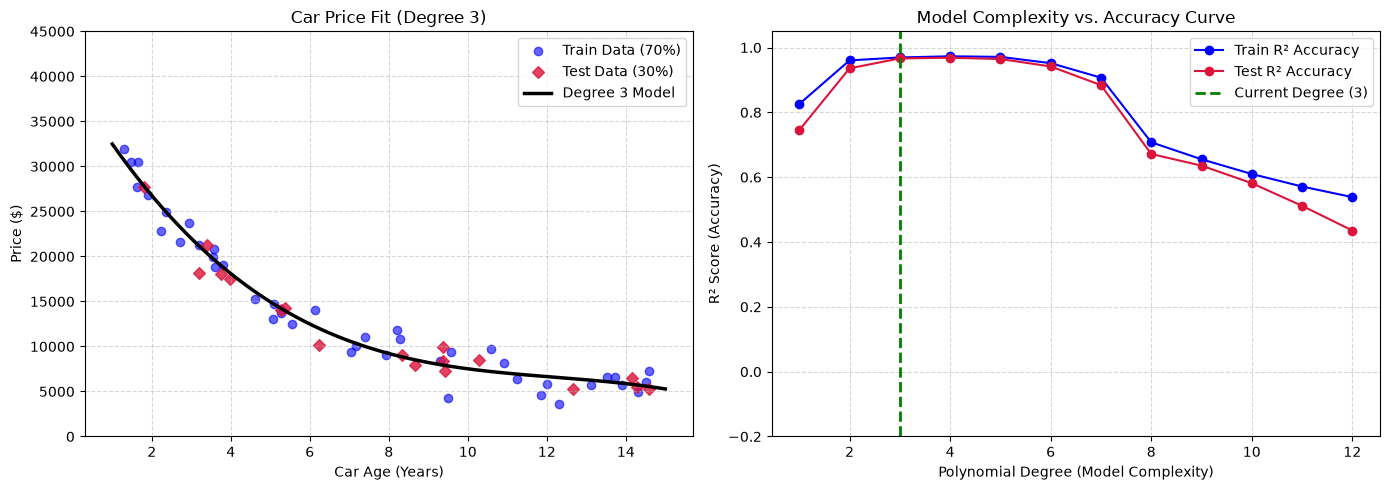

interactive(children=(IntSlider(value=3, continuous_update=False, description='Model Degree:', max=12, min=1),…

In [1]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from ipywidgets import interact
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# 1. Generate Used Car Data
np.random.seed(42)
n_samples = 60
age = np.random.uniform(1, 15, n_samples)
true_price = 35000 * np.exp(-0.25 * age) + 5000
noise = np.random.normal(0, 1500, n_samples)
price = true_price + noise

X = age.reshape(-1, 1)
y = price
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Precompute R² scores across all degrees (1 to 12) for the right chart
degrees_range = list(range(1, 13))
train_r2_all, val_r2_all = [], []

for d in degrees_range:
    m = make_pipeline(PolynomialFeatures(d), LinearRegression())
    m.fit(X_train, y_train)
    train_r2_all.append(r2_score(y_train, m.predict(X_train)))
    val_r2_all.append(r2_score(y_val, m.predict(X_val)))


# 2. Interactive Dashboard Function
def render_dashboard(degree=1):
    # Fit model for selected degree
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)

    # Predictions for plotting fit line
    X_plot = np.linspace(1, 15, 200).reshape(-1, 1)
    y_plot = model.predict(X_plot)

    # Calculate Accuracies
    train_r2 = r2_score(y_train, model.predict(X_train))
    val_r2 = r2_score(y_val, model.predict(X_val))

    # Diagnose Bias / Variance State
    if degree <= 2:
        bias_status = "HIGH BIAS (Underfitting)"
        var_status = "LOW VARIANCE"
        explanation = (
            "Model is too simple to capture the underlying exponential curve."
        )
    elif degree >= 7:
        bias_status = "LOW BIAS"
        var_status = "HIGH VARIANCE (Overfitting)"
        explanation = (
            "Model fits training noise, causing poor generalization on test"
            " data."
        )
    else:
        bias_status = "BALANCED BIAS"
        var_status = "BALANCED VARIANCE (Optimal)"
        explanation = (
            "Model balances complexity well and generalizes cleanly to unseen"
            " test data."
        )

    # Print Text Diagnostics above charts
    print("=" * 78)
    print(f" DIAGNOSTIC: [{bias_status}]  |  [{var_status}]")
    print(
        f" Train Accuracy (R²): {train_r2:.2%}   |   Test Accuracy (R²):"
        f" {val_r2:.2%}"
    )
    print(f" Note: {explanation}")
    print("=" * 78)

    # Plot Visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left Plot: Fit vs Data Points
    ax1.scatter(
        X_train, y_train, color="blue", alpha=0.6, label="Train Data (70%)"
    )
    ax1.scatter(
        X_val,
        y_val,
        color="crimson",
        alpha=0.8,
        marker="D",
        label="Test Data (30%)",
    )
    ax1.plot(
        X_plot,
        y_plot,
        color="black",
        linewidth=2.5,
        label=f"Degree {degree} Model",
    )
    ax1.set_ylim(0, 45000)
    ax1.set_xlabel("Car Age (Years)")
    ax1.set_ylabel("Price ($)")
    ax1.set_title(f"Car Price Fit (Degree {degree})")
    ax1.legend()
    ax1.grid(True, linestyle="--", alpha=0.5)

    # Right Plot: R² Accuracy vs Degree Complexity
    ax2.plot(
        degrees_range,
        train_r2_all,
        marker="o",
        color="blue",
        label="Train R² Accuracy",
    )
    ax2.plot(
        degrees_range,
        val_r2_all,
        marker="o",
        color="crimson",
        label="Test R² Accuracy",
    )
    ax2.axvline(
        x=degree,
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"Current Degree ({degree})",
    )
    ax2.set_ylim(-0.2, 1.05)
    ax2.set_xlabel("Polynomial Degree (Model Complexity)")
    ax2.set_ylabel("R² Score (Accuracy)")
    ax2.set_title("Model Complexity vs. Accuracy Curve")
    ax2.legend()
    ax2.grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


# 3. Render Widget in JupyterLab
interact(
    render_dashboard,
    degree=widgets.IntSlider(
        min=1,
        max=12,
        step=1,
        value=3,
        description="Model Degree:",
        continuous_update=False,  # Smooth rendering on release
    ),
);

In [ ]:
pip install ipywidgets jupyterlab_widgets ipympl